In [1]:
# Install required libraries (run once)
!pip install yfinance scikit-learn pandas numpy matplotlib

In [2]:
# ============================================
# IMPORT LIBRARIES
# ============================================

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [4]:
# ============================================
# CONFIGURATION
# ============================================

STOCK_SYMBOL = "AAPL"   # Change to TSLA, MSFT, etc.
START_DATE = "2020-01-01"
END_DATE = "2024-12-31"
TEST_SIZE = 0.2
RANDOM_STATE = 42

In [6]:
# ============================================
# FUNCTION: LOAD STOCK DATA
# ============================================

def load_stock_data(symbol, start, end):
    """
    Fetch stock data from Yahoo Finance

    Args:
        symbol (str): Stock ticker
        start (str): Start date
        end (str): End date

    Returns:
        pd.DataFrame: Cleaned stock data
    """
    data = yf.download(symbol, start=start, end=end)

    # Select required columns
    data = data[['Open', 'High', 'Low', 'Close', 'Volume']]

    # Drop missing values
    data.dropna(inplace=True)

    return data

In [7]:
# ============================================
# FUNCTION: CREATE FEATURES & TARGET
# ============================================

def create_features(data):
    """
    Create target variable (next day's closing price)

    Args:
        data (pd.DataFrame)

    Returns:
        X, y
    """
    data = data.copy()

    # Shift Close to get next day's price
    data['Target'] = data['Close'].shift(-1)

    # Drop last row (NaN target)
    data.dropna(inplace=True)

    # Features and target
    X = data[['Open', 'High', 'Low', 'Volume']]
    y = data['Target']

    return X, y, data

In [9]:
# ============================================
# FUNCTION: TRAIN MODELS
# ============================================

def train_models(X_train, y_train):
    """
    Train Linear Regression and Random Forest models

    Returns:
        trained models
    """

    # Linear Regression
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)

    # Random Forest
    rf_model = RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )
    rf_model.fit(X_train, y_train)

    return lr_model, rf_model

In [11]:
# ============================================
# FUNCTION: EVALUATE MODELS
# ============================================

def evaluate_model(model, X_test, y_test):
    """
    Evaluate model using RMSE

    Returns:
        predictions, rmse
    """
    predictions = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    return predictions, rmse

In [13]:
# ============================================
# FUNCTION: PREDICT NEXT DAY PRICE
# ============================================

def predict_next_day(model, X):
    """
    Predict next day's closing price

    Returns:
        float: predicted price
    """
    latest_data = X.iloc[-1].values.reshape(1, -1)
    prediction = model.predict(latest_data)[0]

    return prediction

In [16]:
# ============================================
# FUNCTION: PLOT RESULTS
# ============================================

def plot_results(y_test, lr_pred, rf_pred, symbol):
    """
    Plot actual vs predicted values
    """
    plt.figure(figsize=(12,6))

    plt.plot(y_test.values, label="Actual Prices")
    plt.plot(lr_pred, label="Linear Regression", linestyle='dashed')
    plt.plot(rf_pred, label="Random Forest", linestyle='dotted')

    plt.title(f"{symbol} Stock Price Prediction")
    plt.xlabel("Time")
    plt.ylabel("Price")
    plt.legend()

    plt.show()

Loading data...


/tmp/ipykernel_268/1752859814.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol, start=start, end=end)
[*********************100%***********************]  1 of 1 completed


Creating features...
Splitting data...
Training models...
Evaluating models...

Model Performance:
Linear Regression RMSE: 3.10
Random Forest RMSE: 25.70

Predicting next day price...

Next Day Predicted Closing Price:
Linear Regression: 252.54
Random Forest: 193.63

Plotting results...


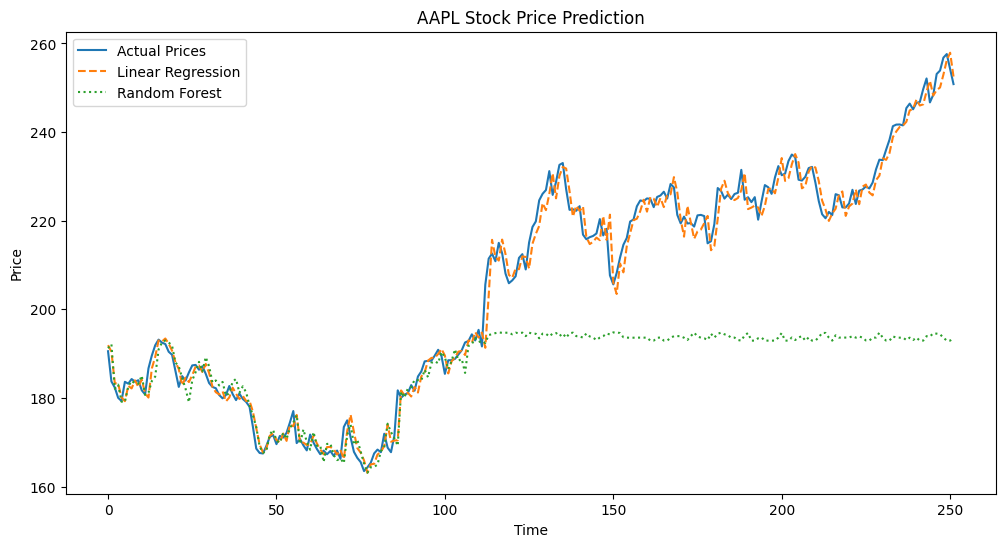

In [17]:
# ============================================
# MAIN EXECUTION PIPELINE
# ============================================

def main():
    print("Loading data...")
    data = load_stock_data(STOCK_SYMBOL, START_DATE, END_DATE)

    print("Creating features...")
    X, y, processed_data = create_features(data)

    print("Splitting data...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, shuffle=False
    )

    print("Training models...")
    lr_model, rf_model = train_models(X_train, y_train)

    print("Evaluating models...")
    lr_pred, lr_rmse = evaluate_model(lr_model, X_test, y_test)
    rf_pred, rf_rmse = evaluate_model(rf_model, X_test, y_test)

    print("\nModel Performance:")
    print(f"Linear Regression RMSE: {lr_rmse:.2f}")
    print(f"Random Forest RMSE: {rf_rmse:.2f}")

    print("\nPredicting next day price...")
    lr_next = predict_next_day(lr_model, X)
    rf_next = predict_next_day(rf_model, X)

    print("\nNext Day Predicted Closing Price:")
    print(f"Linear Regression: {lr_next:.2f}")
    print(f"Random Forest: {rf_next:.2f}")

    print("\nPlotting results...")
    plot_results(y_test, lr_pred, rf_pred, STOCK_SYMBOL)

# Run the pipeline
main()